# Noninteracting Bernal bilayer graphene: eigenpairs and $\rho^{(0)}$

This notebook implements the stage **before Hartree–Fock**: construct the four-band Hamiltonian, diagonalize it, fill its states, and form the initial one-particle density matrix.

The hopping parameters and Hamiltonian follow Eq. (1) of [Aguilar-Méndez, Neupert, and Wagner, *Full, three-quarter, half and quarter Wigner crystals in Bernal bilayer graphene*](https://arxiv.org/abs/2505.09685).

Keep this notebook next to `bernal_initializer.py`. The required packages are NumPy, SciPy, and Matplotlib (`python -m pip install -r requirements.txt`). NumPy diagonalizes the explicit Hermitian matrices; no SCF solver is called.

**Scope:** all four bands are retained. The paper's later projection onto the highest valence band, Wigner-crystal folding, interactions, and symmetry-breaking iterations are subsequent operations.

## 1. Set the physical inputs and momentum grid

- Energies: **eV**; momenta: **Å$^{-1}$**; temperature: **K**.
- `D_eV` is the energy difference between layers. A displacement field specified in V/nm must first be converted to an energy bias.
- The input density is the **total carrier density relative to neutrality**, including both valleys and spins. Negative means holes.
- The default grid is the paper's translation-preserving comparison grid: 1,801 points, hexagon radius $0.12/a$, spacing $0.005/a$.
- Boundary quadrature weights are our explicit numerical choice: full interior weights, half on edges, one third at corners.

The chosen $D=50$ meV and $n=-5\times 10^{11}$ cm$^{-2}$ are editable example conditions.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from bernal_initializer import (
    Parameters, make_hexagonal_grid, hamiltonian, initialize, diagnostics
)

np.set_printoptions(precision=6, suppress=True, linewidth=110)

# Change these inputs and run the notebook again.
parameters = Parameters(D_eV=50e-3)
temperature_K = 0.0
target_density_cm2 = -5e11

grid = make_hexagonal_grid(
    shells=24,
    cutoff_times_a=0.12,
    a_angstrom=parameters.a_angstrom,
)
print("Momentum points per valley:", len(grid.k_Ainv))
print("Mesh:", grid.description)
print("Sublattice basis: (A1, B1, A2, B2)")
print("Input parameters:", parameters)


Momentum points per valley: 1801
Mesh: Triangular hexagon: 24 shells, cutoff*a=0.12, step*a=0.005; boundary-weighted triangular quadrature
Sublattice basis: (A1, B1, A2, B2)
Input parameters: Parameters(D_eV=0.05, a_angstrom=2.46, t0_eV=2.61, t1_eV=0.361, t3_eV=0.283, t4_eV=0.138, delta_prime_eV=0.015)


## 2. Inspect a single Hamiltonian and its eigenvectors

With $z_\tau=\sqrt{3}a(\tau k_x+i k_y)/2$, the factors of $\hbar$ cancel: $v_i\pi=t_i z_\tau$. The function `hamiltonian` constructs the matrix directly in the basis $(A_1,B_1,A_2,B_2)$.

`np.linalg.eigh(h)` returns ascending eigenvalues and a matrix `U` whose **column** `U[:, nu]` is the normalized eigenvector belonging to `energy[nu]`. The momentum below is one illustrative point; the full initialization subsequently uses the entire grid.

In [2]:
k_example = np.array([0.010, 0.005])  # relative to K, in inverse Angstrom
h_example = hamiltonian(k_example, valley=+1, parameters=parameters)
energies_example, U_example = np.linalg.eigh(h_example)

print("h(K + k), in eV:")
print(h_example)
print("Eigenvalues, in meV:")
print(1000 * energies_example)
print("Eigenvectors (one per column):")
print(U_example)
print("Eigenvector norms:", np.linalg.norm(U_example, axis=0))


h(K + k), in eV:
[[ 0.025   +0.j        0.055604-0.027802j -0.00294 +0.00147j  -0.006029-0.003015j]
 [ 0.055604+0.027802j  0.04    +0.j        0.361   +0.j       -0.00294 +0.00147j ]
 [-0.00294 -0.00147j   0.361   -0.j       -0.01    +0.j        0.055604-0.027802j]
 [-0.006029+0.003015j -0.00294 -0.00147j   0.055604+0.027802j -0.025   +0.j      ]]
Eigenvalues, in meV:
[-358.874762  -25.571587   28.537358  385.908991]
Eigenvectors (one per column):
[[ 0.114343-0.j       -0.253006+0.j       -0.953387+0.j       -0.118182+0.j      ]
 [-0.593049-0.31243j   0.162003-0.00783j  -0.034534+0.0059j   -0.642012-0.333117j]
 [ 0.636537+0.335789j  0.000867+0.021218j  0.150208+0.073132j -0.597737-0.310508j]
 [-0.07983 -0.115322j -0.867603-0.395596j  0.227452+0.1009j   -0.054741-0.078647j]]
Eigenvector norms: [1. 1. 1. 1.]


## 3. Globally fill states and construct the initial density matrix

For the four-band space, neutrality corresponds to two occupied states per momentum, spin, and valley. We solve

$$n_{\rm carrier}=\sum_{\tau,s,\mathbf k} w_{\mathbf k}\left[\sum_{\nu=1}^4 f_{\tau s\nu}(\mathbf k)-2\right].$$

Each $w_{\mathbf k}$ represents $d^2k/(2\pi)^2$ in cm$^{-2}$. The same chemical potential applies to **all** momenta, valleys, and spins.

For each flavor block,

$$\rho^{(0)}_{\sigma\sigma'}(\mathbf k)=\sum_\nu f_\nu(\mathbf k)U_{\sigma\nu}(\mathbf k)U^*_{\sigma'\nu}(\mathbf k).$$

At $T=0$, the final degenerate energy shell can have equal fractional occupations to match the requested density on the discrete quadrature. This avoids arbitrarily polarizing a degenerate spin/valley shell. At $T>0$, the code instead solves the Fermi–Dirac number equation.

In [3]:
state = initialize(
    target_density_cm2=target_density_cm2,
    temperature_K=temperature_K,
    parameters=parameters,
    grid=grid,
)
print(f"Chemical potential: {1000*state.mu_eV:.10f} meV")
print(f"Target carrier density: {target_density_cm2:.9e} cm^-2")
print(f"Computed carrier density: {state.actual_density_cm2:.9e} cm^-2")
print(f"Density error: {state.actual_density_cm2-target_density_cm2:.6g} cm^-2")
print("Carrier density per valley/spin, in cm^-2:")
print(state.density_by_flavor_cm2)
print("Energies shape:", state.eigenvalues_eV.shape)
print("Eigenvectors shape:", state.eigenvectors.shape)
print("rho0 shape:", state.rho0.shape)


Chemical potential: -24.9131001632 meV
Target carrier density: -5.000000000e+11 cm^-2
Computed carrier density: -5.000000000e+11 cm^-2
Density error: -0.00146484 cm^-2
Carrier density per valley/spin, in cm^-2:
[[-1.25e+11 -1.25e+11]
 [-1.25e+11 -1.25e+11]]
Energies shape: (2, 2, 1801, 4)
Eigenvectors shape: (2, 2, 1801, 4, 4)
rho0 shape: (2, 2, 1801, 4, 4)


The array order is `(valley, spin, momentum, ...)`, with valley indices `[+1,-1]` and spin indices `[up,down]`. Band indices run from 0 to 3 in Python. `rho0` is dimensionless; its trace is the local band occupation. Integration weights belong in momentum sums, not in each `rho0(k)`.

The notebook uses a symmetric, spin-independent starting Hamiltonian. Equal total populations of the four flavors are a property of this initialization on the symmetric grid.

## 4. Inspect an occupied-state projector sum explicitly

Choose a grid point near the chemical potential in the highest valence band (zero-based band index 1). The following loop is the density-matrix formula written directly in Python.

In [4]:
iv, isp = 0, 0  # K valley, spin up
ik = int(np.argmin(np.abs(state.eigenvalues_eV[iv, isp, :, 1] - state.mu_eV)))
U = state.eigenvectors[iv, isp, ik]
f = state.occupations[iv, isp, ik]

rho_manual = np.zeros((4, 4), dtype=complex)
for nu in range(4):
    u_nu = U[:, nu]
    rho_manual += f[nu] * np.outer(u_nu, u_nu.conj())

np.testing.assert_allclose(rho_manual, state.rho0[iv, isp, ik], atol=1e-13)
print("Selected momentum (inverse Angstrom):", grid.k_Ainv[ik])
print("Energies (meV):", 1000*state.eigenvalues_eV[iv, isp, ik])
print("Occupations:", f)
print("Initial rho at this momentum:")
print(rho_manual)
print("Trace rho:", np.trace(rho_manual).real)
print("Eigenvalues of rho:", np.linalg.eigvalsh(rho_manual))


Selected momentum (inverse Angstrom): [0.001016 0.00176 ]
Energies (meV): [-347.277645  -24.9131     25.018378  377.172367]
Occupations: [1.       0.022212 0.       0.      ]
Initial rho at this momentum:
[[ 0.000489+0.j       -0.00748 +0.012956j  0.008022-0.013894j  0.000488+0.000845j]
 [-0.00748 -0.012956j  0.464883+0.j       -0.498205+0.j        0.008844-0.015318j]
 [ 0.008022+0.013894j -0.498205-0.j        0.533931+0.j       -0.009767+0.016917j]
 [ 0.000488-0.000845j  0.008844+0.015318j -0.009767-0.016917j  0.02291 -0.j      ]]
Trace rho: 1.022212487353243
Eigenvalues of rho: [-0.        0.        0.022212  1.      ]


## 5. Plot the noninteracting bands

The following plots are a line cut $k_y=0$ near valley K. The filling was computed using the two-dimensional grid, not this line cut. Spin gives two identical copies of these four bands.

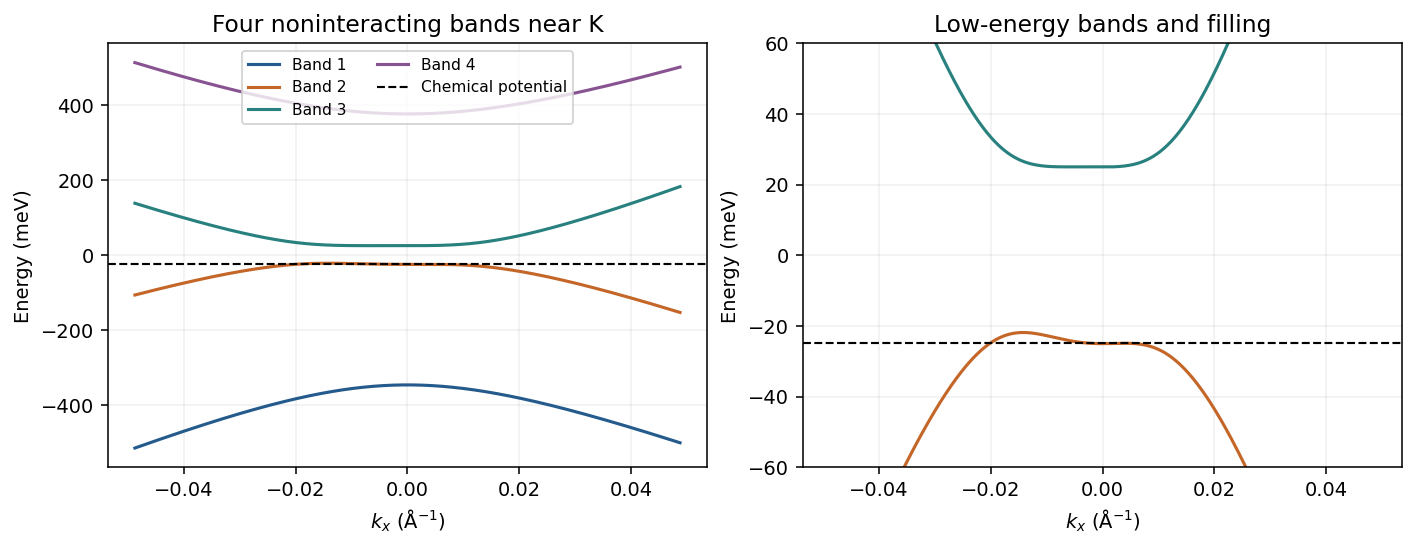

In [5]:
kmax = 0.12 / parameters.a_angstrom
kx = np.linspace(-kmax, kmax, 501)
k_line = np.column_stack((kx, np.zeros_like(kx)))
line_energies = np.linalg.eigvalsh(hamiltonian(k_line, +1, parameters)) * 1000
colors = ["#245b8c", "#c46628", "#28817e", "#885391"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
for band, color in enumerate(colors):
    axes[0].plot(kx, line_energies[:, band], color=color, lw=1.6, label=f"Band {band+1}")
for band in (1, 2):
    axes[1].plot(kx, line_energies[:, band], color=colors[band], lw=1.6, label=f"Band {band+1}")
for ax in axes:
    ax.axhline(1000*state.mu_eV, color="black", ls="--", lw=1.1, label="Chemical potential")
    ax.set_xlabel(r"$k_x$ ($\mathrm{\AA}^{-1}$)")
    ax.set_ylabel("Energy (meV)")
    ax.grid(alpha=0.18)
axes[0].set_title("Four noninteracting bands near K")
axes[0].legend(fontsize=8, loc="upper center", ncol=2)
zoom = max(60., 1200*abs(parameters.D_eV), 1500*abs(state.mu_eV))
axes[1].set_ylim(-zoom, zoom)
axes[1].set_title("Low-energy bands and filling")
plt.show()


## 6. View the momentum grid and valence-band occupations

The right panel displays $1-f$ in band 2, the highest valence band. It is a hole-occupation map for one spin and one valley. The complete `rho0` still contains contributions from all four bands.

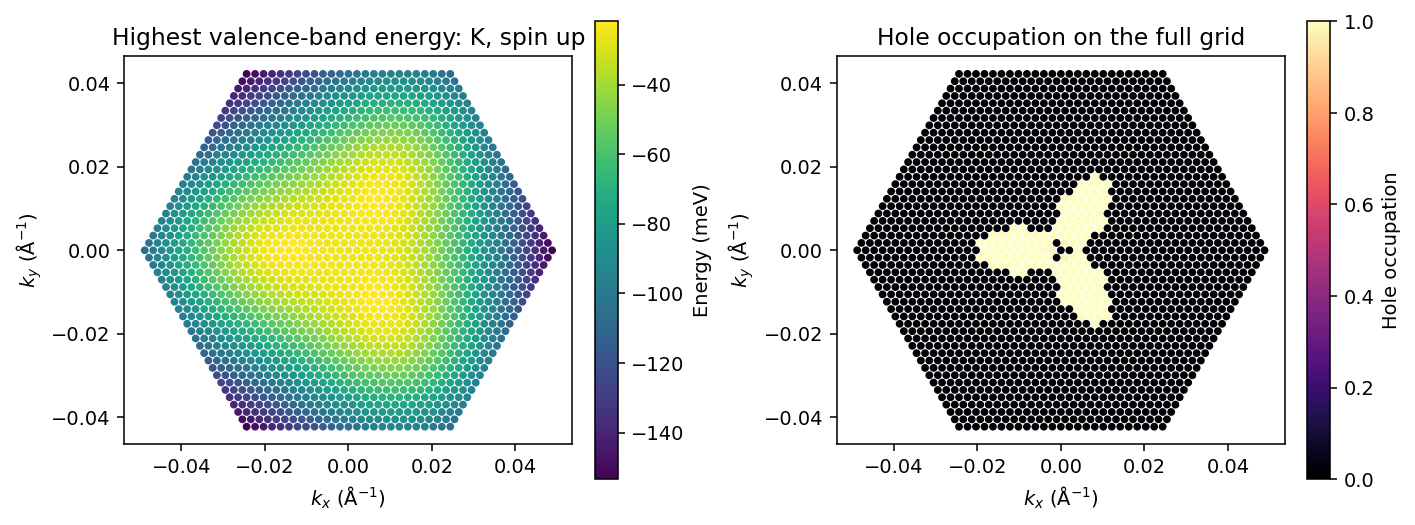

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
x, y = grid.k_Ainv.T
points = axes[0].scatter(x, y, c=1000*state.eigenvalues_eV[0, 0, :, 1],
                         s=9, cmap="viridis", rasterized=True)
fig.colorbar(points, ax=axes[0], label="Energy (meV)", shrink=0.85)
holes = axes[1].scatter(x, y, c=1-state.occupations[0, 0, :, 1],
                        s=9, cmap="magma", vmin=0, vmax=1, rasterized=True)
fig.colorbar(holes, ax=axes[1], label="Hole occupation", shrink=0.85)
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel(r"$k_x$ ($\mathrm{\AA}^{-1}$)")
    ax.set_ylabel(r"$k_y$ ($\mathrm{\AA}^{-1}$)")
axes[0].set_title("Highest valence-band energy: K, spin up")
axes[1].set_title("Hole occupation on the full grid")
plt.show()


## 7. Check normalization and inspect the full internal matrix

The eigenpair residual, Hermiticity error, and commutator $[h_0,\rho^{(0)}]$ should be close to floating-point precision. Density-matrix eigenvalues should lie in $[0,1]$ up to roundoff.

A nonzero idempotency defect is expected at finite temperature or for a fractional zero-temperature Fermi shell. Such a matrix describes an ensemble rather than a single fully occupied-or-empty Slater determinant.

In [7]:
print(json.dumps(diagnostics(state), indent=2))

trace_rho = np.trace(state.rho0, axis1=-2, axis2=-1).real
n_from_rho = np.sum(grid.weights_cm2[None, None, :] * (trace_rho - 2))
print(f"Density recovered directly from rho: {n_from_rho:.9e} cm^-2")

rho_full = state.full_density_matrix()
print("Full internal-matrix shape:", rho_full.shape)
print("Block order: (K,up), (K,down), (K',up), (K',down)")
print("Each block has sublattice order (A1,B1,A2,B2).")


{
  "max_eigenpair_residual_eV": 6.597425008528065e-16,
  "max_orthonormality_error": 1.9984014443252818e-15,
  "max_rho_hermiticity_error": 3.469446951953614e-18,
  "max_commutator_residual_eV": 5.551124678707994e-16,
  "max_trace_occupation_error": 2.6645352591003757e-15,
  "minimum_rho_eigenvalue": -5.561758361445002e-16,
  "maximum_rho_eigenvalue": 1.0000000000000024,
  "max_idempotency_defect": 0.02168951834338275,
  "density_error_cm2": -0.00146484375
}
Density recovered directly from rho: -5.000000000e+11 cm^-2
Full internal-matrix shape: (1801, 16, 16)
Block order: (K,up), (K,down), (K',up), (K',down)
Each block has sublattice order (A1,B1,A2,B2).


## 8. Save the arrays for the next stage

This completes initialization. The archive contains momentum points, quadrature weights, eigenvalues, eigenvectors, occupations, $\mu$, and $\rho^{(0)}$, with input metadata. It can be loaded without this Python module using `np.load`.

For a finite-temperature initialization, change `temperature_K` in the input cell and rerun. To refine the mesh while retaining the cutoff, increase `shells`. The numerical example and checks establish consistency on the chosen finite grid; they do not establish continuum-grid convergence.

In [8]:
output_file = state.save("example_initial_state.npz")
print("Saved:", output_file)
with np.load(output_file, allow_pickle=False) as saved:
    print("Available arrays:", saved.files)
    restored_rho0 = saved["rho0"]
np.testing.assert_array_equal(restored_rho0, state.rho0)


Saved: example_initial_state.npz
Available arrays: ['k_Ainv', 'weights_cm2', 'eigenvalues_eV', 'eigenvectors', 'occupations', 'rho0', 'mu_eV', 'temperature_K', 'target_density_cm2', 'actual_density_cm2', 'metadata_json']
